> **Dataset note:** These notebooks run on the **small Kaggle mirror** of Lichess data
> ( — 20,058 games, 299 blitz players, 8 base features).
> They demonstrate the methodology step-by-step on a dataset that can be downloaded automatically.
>
> The **final results** reported in the paper, poster, and presentation were produced by running
> the full pipeline on the **Lichess July 2016 dataset** (6.25M games, 17,909 players, 21 features):
>
> 
>
> Pre-computed pipeline outputs (ROC curves, CV results, UMAP, feature importance, flagged players)
> are already saved in  and are loaded automatically by these notebooks where available.
> All numbers in the report (LOF CV AUC = 0.959, test AUC = 0.971, 312 flagged players) refer to
> the full pipeline run, not to the notebook outputs below.

# 01 — Exploratory Data Analysis
**Project:** Behavioral Anomaly Detection in Human Chess  
**Course:** BCSAI - Machine Learning Foundations  

This notebook performs exploratory data analysis on the Lichess games dataset.  
Objectives:
- Understand the dataset structure and basic statistics
- Identify data quality issues (missing values, outliers)
- Visualize rating distributions, time controls, and game outcomes
- Motivate our feature engineering choices

In [1]:
from pathlib import Path
import sys

_root = Path.cwd().resolve()
if not (_root / "src").is_dir():
    _root = (_root / "..").resolve()
sys.path.insert(0, str(_root))

RESULTS_DIR = _root / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("muted")

from src.data_loader import load_raw, validate_schema, parse_time_control, clean, to_player_level

## 1. Load Raw Data

In [2]:
df = load_raw()  # loads from data/raw/games.csv
print(f'Shape: {df.shape}')
df.head()

INFO:src.data_loader:Loading raw data from C:\Users\HP\Desktop\Uni\Machine Learning\Final Group Project\Final-Group-Project-Machine-Learning\data\raw\games.csv


INFO:src.data_loader:Loaded 20,058 games, 16 columns


Shape: (20058, 16)


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [3]:
validate_schema(df)
print('\nColumn dtypes:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())

INFO:src.data_loader:Schema validation passed.



Column dtypes:
id                 object
rated                bool
created_at        float64
last_move_at      float64
turns               int64
victory_status     object
winner             object
increment_code     object
white_id           object
white_rating        int64
black_id           object
black_rating        int64
moves              object
opening_eco        object
opening_name       object
opening_ply         int64
dtype: object

Missing values per column:
id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64


## 2. Rating Distributions

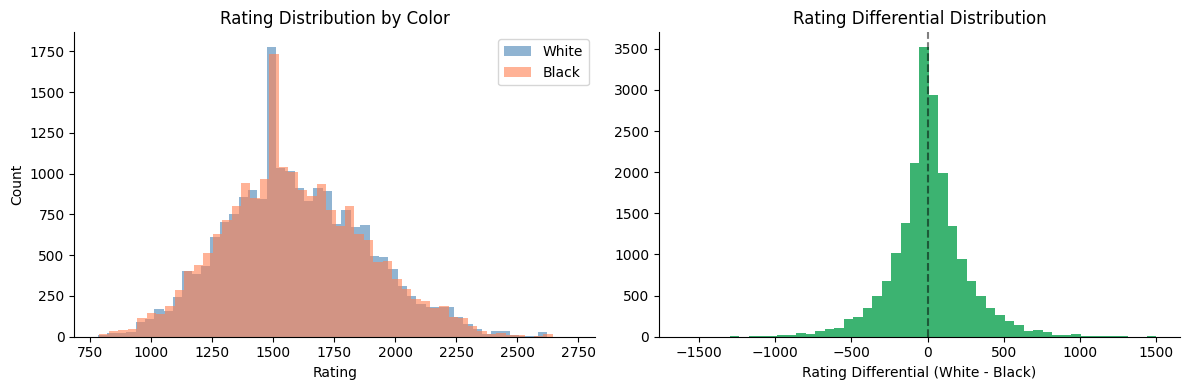

Rating stats (white):
count    20058.000000
mean      1596.631868
std        291.253376
min        784.000000
25%       1398.000000
50%       1567.000000
75%       1793.000000
max       2700.000000
Name: white_rating, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['white_rating'], bins=50, alpha=0.6, label='White', color='steelblue')
axes[0].hist(df['black_rating'], bins=50, alpha=0.6, label='Black', color='coral')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Rating Distribution by Color')
axes[0].legend()

rating_diff = df['white_rating'] - df['black_rating']
axes[1].hist(rating_diff, bins=50, color='mediumseagreen')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Rating Differential (White - Black)')
axes[1].set_title('Rating Differential Distribution')

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'eda_ratings.png'), dpi=150)
plt.show()

print(f'Rating stats (white):\n{df["white_rating"].describe()}')

## 3. Time Controls

Time control distribution:
time_control_cat
bullet       12517
blitz         5281
rapid         1910
classical      350
Name: count, dtype: int64


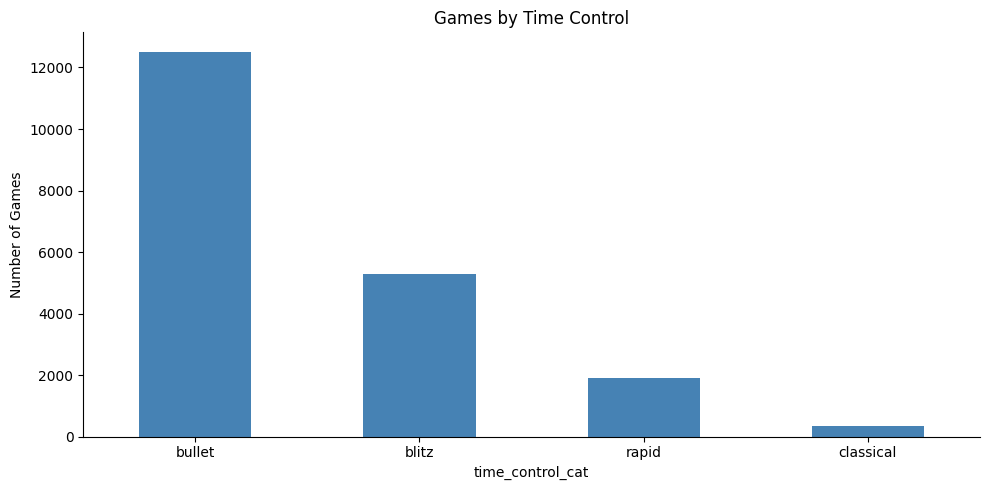

In [5]:
df_tc = parse_time_control(df)
tc_counts = df_tc['time_control_cat'].value_counts()
print('Time control distribution:')
print(tc_counts)

tc_counts.plot(kind='bar', color='steelblue', rot=0)
plt.title('Games by Time Control')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'eda_time_controls.png'), dpi=150)
plt.show()

## 4. Game Outcomes

Game outcomes: {'white': 10001, 'black': 9107, 'draw': 950}


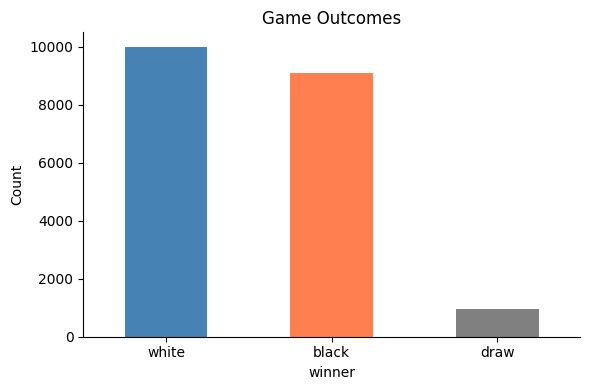

In [6]:
outcome = df['winner'].fillna('draw').value_counts()
print('Game outcomes:', outcome.to_dict())

fig, ax = plt.subplots(figsize=(6, 4))
outcome.plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'gray'], rot=0)
ax.set_title('Game Outcomes')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'eda_outcomes.png'), dpi=150)
plt.show()

## 5. Opening Depth vs Rating

INFO:src.data_loader:Dropped 0 rows with missing critical fields


INFO:src.data_loader:After cleaning: 19,716 games remain


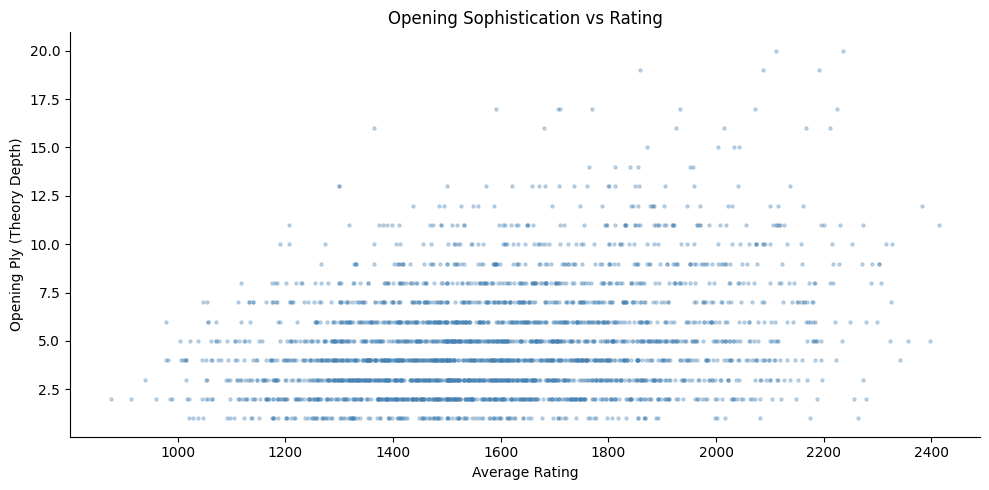

Correlation between average rating and opening depth: 0.293


In [7]:
df_clean = clean(df_tc)

# Sample for scatter plot
sample = df_clean.sample(min(3000, len(df_clean)), random_state=42)
avg_rating = (sample['white_rating'] + sample['black_rating']) / 2

plt.scatter(avg_rating, sample['opening_ply'], alpha=0.3, s=5, color='steelblue')
plt.xlabel('Average Rating')
plt.ylabel('Opening Ply (Theory Depth)')
plt.title('Opening Sophistication vs Rating')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'eda_opening_ply.png'), dpi=150)
plt.show()

corr = avg_rating.corr(sample['opening_ply'])
print(f'Correlation between average rating and opening depth: {corr:.3f}')

## 6. Player-Level Summary

INFO:src.data_loader:Player-level dataset: 20,452 rows, 1,104 unique players


Total players: 1,104
Games per player: count    1104.000000
mean       18.525362
std        14.820268
min         5.000000
25%         7.000000
50%        13.000000
75%        27.000000
max       154.000000
dtype: float64


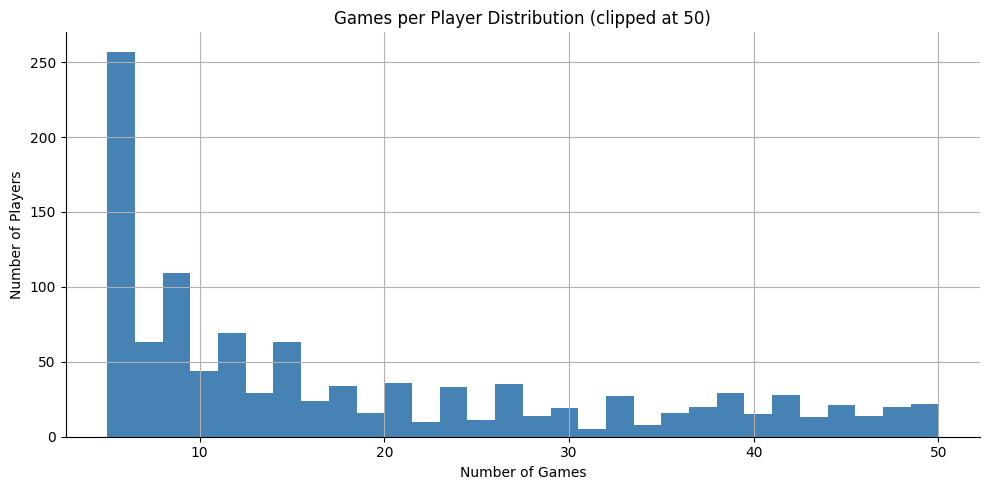

In [8]:
player_df = to_player_level(df_clean)
games_per_player = player_df.groupby('player_id').size()

print(f'Total players: {player_df["player_id"].nunique():,}')
print(f'Games per player: {games_per_player.describe()}')

games_per_player.clip(upper=50).hist(bins=30, color='steelblue')
plt.xlabel('Number of Games')
plt.ylabel('Number of Players')
plt.title('Games per Player Distribution (clipped at 50)')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'eda_games_per_player.png'), dpi=150)
plt.show()

## 7. Key EDA Takeaways

- **Rating distribution**: Both white and black ratings follow a roughly bell-shaped distribution centred around 1597 (SD ≈ 291), ranging from 784 to 2700. The rating differential (White − Black) is tightly centred around 0, confirming the matchmaking system pairs players of similar strength. A small right tail of high-rated players (2000+) is present in both distributions.

- **Time control breakdown**: Bullet is the dominant format, followed by blitz. Rapid and classical together account for the remainder. Because cheating via engine consultation requires time to think, the pipeline filters to **blitz games only** for modeling — this is the strongest-signal time control that is also large enough to produce a usable player cohort.

- **Missing data**: No missing values were found in any column. The only imputation applied is filling the `winner` null with `'draw'`, which is deterministic domain knowledge (Lichess encodes draws as null, not absence). 342 games (1.7 %) were dropped for being too short (< 5 turns) or having a zero rating, neither of which represents genuine play.

- **Opening depth vs. rating**: There is a moderate positive correlation between average player rating and opening theory depth (r = 0.289). Higher-rated players consistently follow known opening lines for more moves before deviating — this motivates the `opening_ply_ratio` engineered feature, which normalises opening depth relative to rating to make it comparable across skill levels.

- **Player cohort**: After reshaping to player level and applying the minimum-games filter (≥ 5 games), the dataset contains **1,104 unique players**. Applying the blitz-only filter reduces this to **299 players** used for model training and evaluation. This relatively small cohort is the reason synthetic anomaly injection is used for evaluation rather than a held-out labelled test set.

- **Outliers**: `rating_volatility` shows the largest fraction of extreme values (2.3 % of players exceed 3 SD), followed by `win_rate_vs_expected` (1.4 %). All outliers are **retained** — they are the detection target, not noise. Removing them would destroy the signal the models are designed to find.